In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
# === Part 1: Load data from yfinance ===
def load_yahoo_data(ticker, start="2020-01-01", end="2025-04-08"):
    df = yf.download(ticker, start=start, end = end)


    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]


    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)


    df['Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Return'].rolling(window=10).std()
    df['Volume_Change'] = df['Volume'].pct_change()

    df.columns = [col[0] if col[1] == '' else col[0] for col in df.columns]


    df.dropna(inplace=True)

    return df


In [ ]:
df1 = load_yahoo_data("SPY")

[*********************100%***********************]  1 of 1 completed


In [ ]:
df1.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Return', 'Volatility',
       'Volume_Change'],
      dtype='object')

In [ ]:
df1

,Open,High,Low,Close,Volume,Return,Volatility,Volume_Change
Date,,,,,,,,
2020-01-16,304.756119,305.883820,304.525033,305.883820,54050300,0.008318,0.005290,-0.249891
2020-01-17,306.604760,307.048427,305.819062,306.835846,95846000,0.003112,0.004123,0.773274
2020-01-21,305.865376,307.048535,305.791440,306.235107,77742400,-0.001958,0.004381,-0.188882
2020-01-22,307.103968,307.760272,306.114942,306.272064,48914900,0.000121,0.004085,-0.370808
2020-01-23,305.615790,307.039288,304.488090,306.623322,51963000,0.001147,0.003993,0.062314
...,...,...,...,...,...,...,...,...
2025-04-01,557.450012,562.940002,553.679993,560.969971,54609600,0.002824,0.010855,-0.427141
2025-04-02,555.049988,567.419983,554.809998,564.520020,76014500,0.006328,0.010451,0.391962
2025-04-03,545.109985,547.969971,536.700012,536.700012,125986000,-0.049281,0.018790,0.657394


In [ ]:
# === Part 2: Technical indicators ===
def compute_tsi(close, r=25, s=13):
    momentum = close.diff()
    abs_momentum = momentum.abs()
    ema1 = momentum.ewm(span=r, min_periods=1).mean()
    ema2 = ema1.ewm(span=s, min_periods=1).mean()
    abs_ema1 = abs_momentum.ewm(span=r, min_periods=1).mean()
    abs_ema2 = abs_ema1.ewm(span=s, min_periods=1).mean()
    tsi = 100 * ema2 / abs_ema2
    return tsi

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

def add_features(data):
    data['TSI'] = compute_tsi(data['Close'])
    data['RSI'] = compute_rsi(data['Close'])
    data.dropna(inplace=True)
    return data

# === Part 3: Label creation ===
def create_labels(data, forward_days=15):
    future_return = data['Close'].shift(-forward_days) / data['Close'] - 1
    data['Label'] = (future_return > 0).astype(int)
    return data.dropna()

# === Part 4: Data Preparation ===
def prepare_data_from_yahoo(ticker):
    data = load_yahoo_data(ticker)
    data = add_features(data)
    data = create_labels(data, forward_days=15)
    features = ['Return', 'Volatility', 'Volume_Change', 'TSI', 'RSI']
    scaler = StandardScaler()
    X = scaler.fit_transform(data[features])
    y = data['Label']
    X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
        X, y, data, test_size=0.2, shuffle=False)
    return X_train, X_test, y_train, y_test, df_test

# === Part 5: Model Training ===
def train_xgboost_model(X_train, y_train):
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    model.fit(X_train, y_train)
    return model

# === Part 6: Backtest (15-day holding period) ===
def backtest_predictions_hold_15_days(model, X_test, df_test, threshold=0.5, holding_period=15):
    prob = model.predict_proba(X_test)[:, 1]
    df_test = df_test.copy()
    df_test['Signal'] = (prob > threshold).astype(int)
    df_test['Position'] = 0
    for i in range(len(df_test) - holding_period):
        if df_test.iloc[i]['Signal'] == 1:
            df_test.iloc[i:i + holding_period, df_test.columns.get_loc('Position')] = 1
    df_test['Next_Open'] = df_test['Open'].shift(-1)
    df_test['Returns'] = df_test['Next_Open'].pct_change()
    df_test['Strategy_Returns'] = df_test['Returns'] * df_test['Position']
    df_test['Cumulative_Strategy'] = (1 + df_test['Strategy_Returns']).cumprod()
    df_test['Cumulative_BuyHold'] = (1 + df_test['Returns']).cumprod()
    return df_test

# === Part 7: Metrics Comparison ===
def calculate_performance_metrics(data, return_col='Strategy_Returns', rf_rate=0.01):
    daily_returns = data[return_col].dropna()
    cumulative = (1 + daily_returns).cumprod()
    total_days = (data.index[-1] - data.index[0]).days
    annual_return = cumulative.iloc[-1] ** (365 / total_days) - 1
    annual_volatility = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = (annual_return - rf_rate) / annual_volatility if annual_volatility != 0 else np.nan
    negative_vol = daily_returns[daily_returns < 0].std() * np.sqrt(252)
    sortino_ratio = (annual_return - rf_rate) / negative_vol if negative_vol != 0 else np.nan
    return {
        'Annual Return': annual_return,
        'Annual Volatility': annual_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Sortino Ratio': sortino_ratio
    }

def compare_strategies(df_test):
    strat_metrics = calculate_performance_metrics(df_test, return_col='Strategy_Returns')
    hold_metrics = calculate_performance_metrics(df_test, return_col='Returns')
    comparison = pd.DataFrame({
        'Metric': list(strat_metrics.keys()),
        'XGBoost Strategy': list(strat_metrics.values()),
        'Buy & Hold': list(hold_metrics.values())
    })
    return comparison

# === Part 8: Visualize trades and drawdowns ===
def max_drawdown(series):
    peak = series.cummax()
    drawdown = (series - peak) / peak
    return drawdown.min()

def add_trade_analysis_and_plot(df_test):
    import matplotlib.dates as mdates
    if not isinstance(df_test.index, pd.DatetimeIndex):
        df_test.index = pd.to_datetime(df_test.index)
    df_test['Buy_Entry'] = (df_test['Position'].diff() == 1).astype(int)
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(df_test.index, df_test['Cumulative_Strategy'], label='XGBoost Strategy', color='blue')
    ax1.plot(df_test.index, df_test['Cumulative_BuyHold'], label='Buy & Hold', color='gray', linestyle='--')
    buy_dates = df_test[df_test['Buy_Entry'] == 1].index
    ax1.scatter(buy_dates, df_test.loc[buy_dates, 'Cumulative_Strategy'],
                color='green', marker='^', label='Buy Entry', zorder=5)
    ax1.set_ylabel("Cumulative Return")
    ax1.set_title("Strategy vs Buy & Hold (with Buy Entries)")
    ax1.grid(True)
    ax1.legend(loc='upper left')
    ax2 = ax1.twinx()
    ax2.plot(df_test.index, df_test['Position'], label='Position', color='orange', alpha=0.3)
    ax2.set_ylabel("Position (1 = In, 0 = Out)")
    ax2.set_yticks([0, 1])
    ax2.set_ylim(-0.1, 1.1)
    fig.tight_layout()
    plt.show()

def show_strategy_summary(df_test):
    df_test['Buy_Entry'] = (df_test['Position'].diff() == 1).astype(int)
    entry_times = df_test[df_test['Buy_Entry'] == 1].index
    print("🔔 Strategy Buy Entries:")
    for dt in entry_times:
        print(f" - {dt.strftime('%Y-%m-%d')}")
    print(f"\n📈 Total Trades: {len(entry_times)}")
    print(f"📉 Max Drawdown (Strategy): {max_drawdown(df_test['Cumulative_Strategy']):.2%}")
    print(f"📉 Max Drawdown (Buy & Hold): {max_drawdown(df_test['Cumulative_BuyHold']):.2%}")
    add_trade_analysis_and_plot(df_test)

# === Part 9: Master run function ===
def run_strategy_from_yahoo_return_all(ticker):
    print(f"Running mean reversion strategy with XGBoost using yahoo finance: {ticker}")
    X_train, X_test, y_train, y_test, df_test = prepare_data_from_yahoo(ticker)
    model = train_xgboost_model(X_train, y_train)
    print("Model Performance:")
    print(classification_report(y_test, model.predict(X_test)))
    df_backtest = backtest_predictions_hold_15_days(model, X_test, df_test)
    return model, X_test, df_test, df_backtest


Running mean reversion strategy with XGBoost using yahoo finance: SPY


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:49:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model Performance:
              precision    recall  f1-score   support

           0       0.35      0.25      0.29        97
           1       0.59      0.70      0.64       150

    accuracy                           0.52       247
   macro avg       0.47      0.47      0.46       247
weighted avg       0.49      0.52      0.50       247

              Metric  XGBoost Strategy  Buy & Hold
0      Annual Return          0.071893    0.071893
1  Annual Volatility          0.205280    0.205280
2       Sharpe Ratio          0.301506    0.301506
3      Sortino Ratio          0.359552    0.359552
🔔 Strategy Buy Entries:

📈 Total Trades: 0
📉 Max Drawdown (Strategy): -19.77%
📉 Max Drawdown (Buy & Hold): -19.77%


<ipython-input-19-c74e3018c396>:63: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_test['Returns'] = df_test['Next_Open'].pct_change()


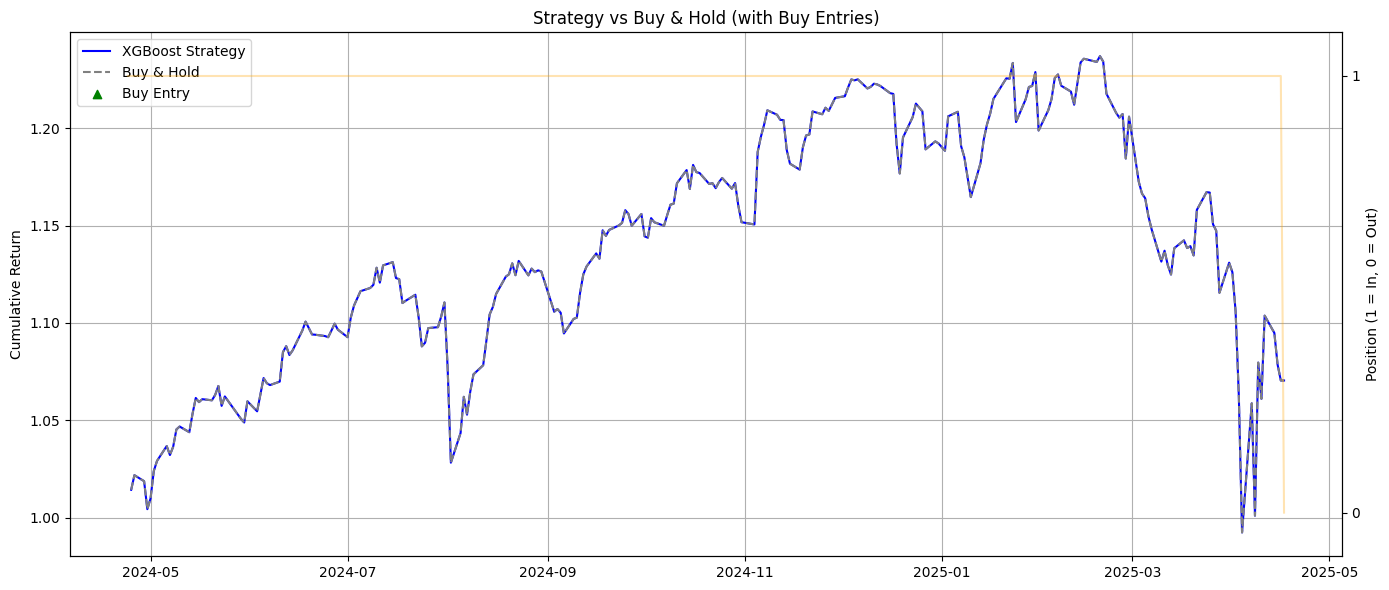

In [ ]:
model, X_test, df_test, df_backtest = run_strategy_from_yahoo_return_all("SPY")
compare_df = compare_strategies(df_backtest)
print(compare_df)
show_strategy_summary(df_backtest)

In [ ]:
def load_excel_data(file_path):
    df = pd.read_excel(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df = df.sort_index()
    df['Return'] = df['Close'].pct_change()
    df['Volatility'] = df['Return'].rolling(10).std()
    df['Volume_Change'] = df['Volume'].pct_change()
    df.dropna(inplace=True)
    return df

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df2 = load_excel_data("/content/drive/MyDrive/UTY/STRATEGY/MEAN REVERSION/SPY_mean_reversion_data.xlsx")

In [ ]:
df2

,Open,High,Low,Close,Volume,Return,Volatility,Volume_Change
Date,,,,,,,,
2020-01-16 05:00:00,329.70,330.9200,329.45,330.92,54222965,0.008318,0.005290,-0.248691
2020-01-17 05:00:00,331.70,332.1800,331.07,331.95,95534216,0.003113,0.004123,0.761877
2020-01-21 05:00:00,330.90,332.1800,330.82,331.30,77966322,-0.001958,0.004381,-0.183891
2020-01-22 05:00:00,332.24,332.9500,331.17,331.34,49084053,0.000121,0.004086,-0.370445
2020-01-23 05:00:00,330.63,332.1682,329.41,331.72,52081148,0.001147,0.003993,0.061060
...,...,...,...,...,...,...,...,...
2025-04-01 04:00:00,557.45,562.9400,553.68,560.97,54576641,0.002825,0.010897,-0.426283
2025-04-02 04:00:00,555.05,567.4200,554.81,564.52,76007044,0.006328,0.010480,0.392666
2025-04-03 04:00:00,545.11,547.9700,536.70,536.70,125426398,-0.049281,0.018724,0.650194


In [ ]:
diff = df1.compare(df2)

ValueError: Can only compare identically-labeled (both index and columns) DataFrame objects

In [ ]:
print("Index equal:", df1.index.equals(df2.index))
print("Columns equal:", df1.columns.equals(df2.columns))


Index equal: False
Columns equal: True


In [ ]:
df1_aligned, df2_aligned = df1.align(df2)
diff = df1_aligned.compare(df2_aligned)



In [ ]:
diff

Open                High                 Low  \
                           self   other        self   other        self   
Date                                                                      
2020-01-16 00:00:00  304.756119     NaN  305.883820     NaN  304.525033   
2020-01-16 05:00:00         NaN  329.70         NaN  330.92         NaN   
2020-01-17 00:00:00  306.604760     NaN  307.048427     NaN  305.819062   
2020-01-17 05:00:00         NaN  331.70         NaN  332.18         NaN   
2020-01-21 00:00:00  305.865376     NaN  307.048535     NaN  305.791440   
...                         ...     ...         ...     ...         ...   
2025-04-03 04:00:00         NaN  545.11         NaN  547.97         NaN   
2025-04-04 00:00:00  523.669983     NaN  525.869995     NaN  505.059998   
2025-04-04 04:00:00         NaN  523.67         NaN  525.87         NaN   
2025-04-07 00:00:00  489.190002     NaN  523.169983     NaN  481.799988   
2025-04-07 04:00:00         NaN  489.19         NaN  523.17         NaN   

                                  Close               Volume               \
                      other        self   other         self        other   
Date                                                                        
2020-01-16 00:00:00     NaN  305.883820     NaN   54050300.0          NaN   
2020-01-16 05:00:00  329.45         NaN  330.92          NaN   54222965.0   
2020-01-17 00:00:00     NaN  306.835846     NaN   95846000.0          NaN   
2020-01-17 05:00:00  331.07         NaN  331.95          NaN   95534216.0   
2020-01-21 00:00:00     NaN  306.235107     NaN   77742400.0          NaN   
...                     ...         ...     ...          ...          ...   
2025-04-03 04:00:00  536.70         NaN  536.70          NaN  125426398.0   
2025-04-04 00:00:00     NaN  505.279999     NaN  217965100.0          NaN   
2025-04-04 04:00:00  505.06         NaN  505.28          NaN  217902831.0   
2025-04-07 00:00:00     NaN  504.380005     NaN  256611400.0          NaN   
2025-04-07 04:00:00  481.80         NaN  504.38          NaN  256602634.0   

                       Return           Volatility           Volume_Change  \
                         self     other       self     other          self   
Date                                                                         
2020-01-16 00:00:00  0.008318       NaN   0.005290       NaN     -0.249891   
2020-01-16 05:00:00       NaN  0.008318        NaN  0.005290           NaN   
2020-01-17 00:00:00  0.003112       NaN   0.004123       NaN      0.773274   
2020-01-17 05:00:00       NaN  0.003113        NaN  0.004123           NaN   
2020-01-21 00:00:00 -0.001958       NaN   0.004381       NaN     -0.188882   
...                       ...       ...        ...       ...           ...   
2025-04-03 04:00:00       NaN -0.049281        NaN  0.018724           NaN   
2025-04-04 00:00:00 -0.058543       NaN   0.025164       NaN      0.730074   
2025-04-04 04:00:00       NaN -0.058543        NaN  0.025164           NaN   
2025-04-07 00:00:00 -0.001781       NaN   0.023390       NaN      0.177305   
2025-04-07 04:00:00       NaN -0.001781        NaN  0.023390           NaN   

                               
                        other  
Date                           
2020-01-16 00:00:00       NaN  
2020-01-16 05:00:00 -0.248691  
2020-01-17 00:00:00       NaN  
2020-01-17 05:00:00  0.761877  
2020-01-21 00:00:00       NaN  
...                       ...  
2025-04-03 04:00:00  0.650194  
2025-04-04 00:00:00       NaN  
2025-04-04 04:00:00  0.737296  
2025-04-07 00:00:00       NaN  
2025-04-07 04:00:00  0.177601  

[2626 rows x 16 columns]